# Hybrid Neuro-Symbolic Intrusion Detection System (NS-IDS)

## 1. Introduction

Intrusion Detection Systems (IDS) face a fundamental trade-off:

- High predictive accuracy
- Strong explainability

Deep neural models can detect complex traffic patterns, but they often behave as black boxes. In contrast, rule-based systems are interpretable and transparent, but they typically struggle to adapt to complex and evolving network behaviors.

This notebook implements a **Hybrid Neuro-Symbolic IDS architecture** composed of three complementary layers:

1. **Neural Learning Layer (CNN)** for deep traffic pattern detection.
2. **Machine Learning Layer (XGBoost)** for robust tabular classification.
3. **Symbolic Reasoning Layer** for interpretable intrusion rules.

The final hybrid decision integrates:

- Neural confidence
- Machine learning probability
- Symbolic reasoning confidence

This architecture aims to improve **trustworthy cybersecurity AI systems** by combining strong detection capability with interpretable evidence that can be audited by security analysts.

In [1]:
# Core setup and reusable utilities
from __future__ import annotations

import json
import random
import textwrap
import warnings
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy import sparse

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.tree import DecisionTreeClassifier, export_text, _tree
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Resolve project root regardless of whether the notebook is run from root or notebooks/
if (Path.cwd() / "src").exists():
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise FileNotFoundError("Could not locate project root containing src/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    build_preprocessing_pipeline,
    clean_data,
    load_data,
    split_features,
    train_test_split_data,
)

# TensorFlow is required for the CNN layer in this notebook
try:
    import tensorflow as tf

    tf.random.set_seed(RANDOM_STATE)
    TF_AVAILABLE = True
except Exception as exc:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = exc


def to_dense(matrix):
    if sparse.issparse(matrix):
        return matrix.toarray()
    return np.asarray(matrix)


def compute_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "FPR": fpr,
        "Brier Score": brier_score_loss(y_true, y_proba),
    }


def predict_proba_fallback(model, X_primary, X_fallback=None):
    # Supports models with predict_proba, decision_function, or only predict
    try:
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X_primary)[:, 1]
        if hasattr(model, "decision_function"):
            scores = model.decision_function(X_primary)
            scores = np.asarray(scores, dtype=float)
            min_s = float(np.min(scores))
            max_s = float(np.max(scores))
            if np.isclose(min_s, max_s):
                return np.full_like(scores, 0.5, dtype=float)
            return (scores - min_s) / (max_s - min_s)
        return np.asarray(model.predict(X_primary), dtype=float)
    except Exception:
        if X_fallback is None:
            raise
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X_fallback)[:, 1]
        if hasattr(model, "decision_function"):
            scores = model.decision_function(X_fallback)
            scores = np.asarray(scores, dtype=float)
            min_s = float(np.min(scores))
            max_s = float(np.max(scores))
            if np.isclose(min_s, max_s):
                return np.full_like(scores, 0.5, dtype=float)
            return (scores - min_s) / (max_s - min_s)
        return np.asarray(model.predict(X_fallback), dtype=float)


DATA_PATH = PROJECT_ROOT / "data" / "processed" / "nsl_kdd_processed.csv"
CNN_PATH = PROJECT_ROOT / "models" / "cnn" / "cnn_model_2_deep.keras"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")

Project root: c:\Users\gudal\OneDrive\Desktop\ShockAwareNeuroSymbolic
Dataset path: c:\Users\gudal\OneDrive\Desktop\ShockAwareNeuroSymbolic\data\processed\nsl_kdd_processed.csv


## 2. Load Dataset

We load the processed NSL-KDD dataset from:

- `data/processed/nsl_kdd_processed.csv`

The target variable is:

- `attack_binary`

We use the preprocessing utilities from `src/preprocessing.py` and apply a stratified split:

- `test_size=0.2`
- `random_state=42`
- `stratify=y`

Diagnostics reported below:

- Dataset size
- Number of features
- Attack ratio

In [6]:
# Section 2: Data loading and preprocessing
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = load_data(DATA_PATH)
df = clean_data(df)
X, y = split_features(df, target_column="attack_binary")

# Prevent target leakage from alternate label columns that encode attack identity
leakage_candidates = ["attack", "label", "class", "target"]
leakage_columns = [col for col in leakage_candidates if col in X.columns]
if leakage_columns:
    X = X.drop(columns=leakage_columns)
    print(f"Dropped leakage columns from features: {leakage_columns}")

X_train_raw, X_test_raw, y_train, y_test = train_test_split_data(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

preprocessor = build_preprocessing_pipeline(X_train_raw)
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out().tolist()

print("Dataset diagnostics")
print("-" * 60)
print(f"Total samples: {len(df):,}")
print(f"Total features: {X.shape[1]}")
print(f"Train samples: {X_train_raw.shape[0]:,}")
print(f"Test samples: {X_test_raw.shape[0]:,}")
print(f"Attack ratio (overall): {y.mean():.4f}")
print(f"Attack ratio (train):   {y_train.mean():.4f}")
print(f"Attack ratio (test):    {y_test.mean():.4f}")
print(f"Transformed feature space: {X_train.shape[1]}")

display(df.head())

[preprocessing] detected target column: attack_binary
Dropped leakage columns from features: ['attack']
[preprocessing] number of categorical features: 3
[preprocessing] number of numeric features: 38
Dataset diagnostics
------------------------------------------------------------
Total samples: 148,517
Total features: 41
Train samples: 118,813
Test samples: 29,704
Attack ratio (overall): 0.4812
Attack ratio (train):   0.4812
Attack ratio (test):    0.4812
Transformed feature space: 121


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,attack_binary
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,0


## 3. Train XGBoost Model

The machine learning layer uses XGBoost for high-performance tabular intrusion classification.

Hyperparameters:

- `n_estimators=200`
- `max_depth=6`
- `learning_rate=0.1`
- `subsample=0.8`
- `colsample_bytree=0.8`
- `random_state=42`

We compute:

- `xgb_proba`
- standard detection metrics
- calibration metric (`Brier Score`)

In [7]:
# Section 3: XGBoost training and evaluation
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

xgb_metrics = compute_metrics(y_test, xgb_pred, xgb_proba)
xgb_results_df = pd.DataFrame([xgb_metrics], index=["XGBoost"])

display(xgb_results_df.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FPR,Brier Score
XGBoost,0.9956,0.997,0.9938,0.9954,0.9999,0.9999,0.0028,0.0031


## 4. Load or Train CNN Model

The neural layer uses a 1D CNN over the transformed feature sequence (`samples, features, 1`).

Architecture:

- Input
- Conv1D(32, kernel_size=3) + ReLU
- Conv1D(64, kernel_size=3) + ReLU
- MaxPooling1D
- Dropout(0.3)
- Flatten
- Dense(128)
- Output Dense(1, sigmoid)

If `models/cnn/cnn_model_2_deep.keras` exists, it is loaded. Otherwise, the model is retrained and saved.

In [9]:
# Section 4: CNN load-or-train pipeline
if not TF_AVAILABLE:
    raise ImportError(
        "TensorFlow is required for the CNN layer. "
        f"Import error: {TF_IMPORT_ERROR}"
    )

X_train_cnn = to_dense(X_train).astype(np.float32)
X_test_cnn = to_dense(X_test).astype(np.float32)

n_features = X_train_cnn.shape[1]
X_train_cnn = X_train_cnn.reshape((-1, n_features, 1))
X_test_cnn = X_test_cnn.reshape((-1, n_features, 1))


def build_cnn_model(num_features):
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(num_features, 1)),
            tf.keras.layers.Conv1D(32, kernel_size=3, activation="relu"),
            tf.keras.layers.Conv1D(64, kernel_size=3, activation="relu"),
            tf.keras.layers.MaxPooling1D(pool_size=2),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


should_train = True
if CNN_PATH.exists():
    cnn_model = tf.keras.models.load_model(CNN_PATH)
    loaded_feature_dim = int(cnn_model.input_shape[1])
    if loaded_feature_dim == n_features:
        should_train = False
        print(f"Loaded existing CNN model from: {CNN_PATH}")
    else:
        print(
            "Existing CNN model input dimension does not match current data "
            f"({loaded_feature_dim} vs {n_features}). Retraining."
        )

if should_train:
    tf.random.set_seed(RANDOM_STATE)
    cnn_model = build_cnn_model(n_features)

    history = cnn_model.fit(
        X_train_cnn,
        y_train,
        validation_split=0.1,
        epochs=10,
        batch_size=128,
        verbose=1,
    )

    CNN_PATH.parent.mkdir(parents=True, exist_ok=True)
    cnn_model.save(CNN_PATH)
    print(f"Saved retrained CNN model to: {CNN_PATH}")

cnn_proba = cnn_model.predict(X_test_cnn, verbose=0).ravel()
cnn_pred = (cnn_proba >= 0.5).astype(int)

cnn_metrics = compute_metrics(y_test, cnn_pred, cnn_proba)
cnn_results_df = pd.DataFrame([cnn_metrics], index=["CNN"])

display(cnn_results_df.round(4))

Existing CNN model input dimension does not match current data (160 vs 121). Retraining.
Epoch 1/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9648 - loss: 0.0953 - val_accuracy: 0.9819 - val_loss: 0.0480
Epoch 2/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9824 - loss: 0.0494 - val_accuracy: 0.9874 - val_loss: 0.0373
Epoch 3/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9852 - loss: 0.0420 - val_accuracy: 0.9890 - val_loss: 0.0329
Epoch 4/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9865 - loss: 0.0373 - val_accuracy: 0.9887 - val_loss: 0.0309
Epoch 5/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9872 - loss: 0.0361 - val_accuracy: 0.9886 - val_loss: 0.0304
Epoch 6/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9881 - loss: 0.0328 - val_accuracy: 0.9902 - val_loss: 0.0278
Epoch 7/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9887 - loss: 0.0310 - val_accuracy: 0.9895 - val_loss: 0.0274
E

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FPR,Brier Score
CNN,0.9896,0.9887,0.9896,0.9892,0.9995,0.9995,0.0104,0.0076


## 5. Symbolic Rule Generation

Two complementary symbolic sources are used:

1. **Decision Tree rule extraction** (`DecisionTreeClassifier(max_depth=4)`)
2. **Domain cybersecurity intrusion rules** derived from NSL-KDD behavioral signals

The tree-generated and domain rules are merged into one unified symbolic rule catalog, then printed in interpretable IF-THEN form.

In [10]:
# Section 5: Build symbolic rules (tree + domain knowledge)
dtree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dtree.fit(X_train, y_train)

feature_index = {name: i for i, name in enumerate(feature_names)}


def extract_attack_tree_rules(tree_model, feature_names):
    tree_ = tree_model.tree_
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            feat_name = feature_names[tree_.feature[node]]
            threshold = float(tree_.threshold[node])

            recurse(tree_.children_left[node], conditions + [(feat_name, "<=", threshold)])
            recurse(tree_.children_right[node], conditions + [(feat_name, ">", threshold)])
        else:
            values = tree_.value[node][0]
            total = float(values.sum())
            attack_prob = float(values[1] / total) if total > 0 else 0.0
            pred_class = int(np.argmax(values))

            if pred_class == 1:
                rule_id = f"TREE_RULE_{len(rules) + 1}"
                weight = max(0.10, min(0.35, attack_prob * 0.35))
                condition_text = " AND ".join([f"{f} {op} {thr:.4f}" for f, op, thr in conditions])
                rules.append(
                    {
                        "id": rule_id,
                        "source": "decision_tree",
                        "weight": float(weight),
                        "conditions": conditions,
                        "text": f"IF {condition_text} THEN attack_confidence += {weight:.2f}",
                    }
                )

    recurse(0, [])
    return rules


def evaluate_tree_rule(transformed_row_vector, rule):
    for feature_name, operator, threshold in rule["conditions"]:
        idx = feature_index.get(feature_name)
        if idx is None:
            return False
        value = float(transformed_row_vector[idx])
        if operator == "<=" and not (value <= threshold):
            return False
        if operator == ">" and not (value > threshold):
            return False
    return True


tree_rules = extract_attack_tree_rules(dtree, feature_names)

# Domain thresholds estimated from train split for reproducibility
dst_host_count_threshold = (
    float(X_train_raw["dst_host_count"].quantile(0.90))
    if "dst_host_count" in X_train_raw.columns
    else 0.0
)
same_srv_rate_threshold = (
    float(X_train_raw["same_srv_rate"].quantile(0.25))
    if "same_srv_rate" in X_train_raw.columns
    else 0.0
)
src_bytes_high_threshold = (
    float(X_train_raw["src_bytes"].quantile(0.90))
    if "src_bytes" in X_train_raw.columns
    else 0.0
)
dst_bytes_low_threshold = (
    float(X_train_raw["dst_bytes"].quantile(0.10))
    if "dst_bytes" in X_train_raw.columns
    else 0.0
)

domain_rules = [
    {
        "id": "DOMAIN_RULE_1_SYN_FLOOD",
        "source": "domain",
        "weight": 0.25,
        "conditions": [
            ("serror_rate", ">", 0.7),
            ("srv_serror_rate", ">", 0.7),
        ],
        "text": "IF serror_rate > 0.7 AND srv_serror_rate > 0.7 THEN attack_confidence += 0.25",
    },
    {
        "id": "DOMAIN_RULE_2_BRUTE_FORCE",
        "source": "domain",
        "weight": 0.20,
        "conditions": [
            ("logged_in", "==", 0),
            ("num_failed_logins", ">", 3),
        ],
        "text": "IF logged_in == 0 AND num_failed_logins > 3 THEN attack_confidence += 0.20",
    },
    {
        "id": "DOMAIN_RULE_3_PORT_SCAN",
        "source": "domain",
        "weight": 0.20,
        "conditions": [
            ("dst_host_count", ">", dst_host_count_threshold),
            ("same_srv_rate", "<", same_srv_rate_threshold),
        ],
        "text": (
            "IF dst_host_count > dynamic_threshold AND same_srv_rate < dynamic_threshold "
            "THEN attack_confidence += 0.20"
        ),
    },
    {
        "id": "DOMAIN_RULE_4_SUSPICIOUS_FLOW",
        "source": "domain",
        "weight": 0.15,
        "conditions": [
            ("src_bytes", ">", src_bytes_high_threshold),
            ("dst_bytes", "<", dst_bytes_low_threshold),
        ],
        "text": (
            "IF src_bytes is very high AND dst_bytes is very low "
            "THEN attack_confidence += 0.15"
        ),
    },
]


def evaluate_domain_rule(raw_row, rule):
    for feature_name, operator, threshold in rule["conditions"]:
        if feature_name not in raw_row.index:
            return False
        value = raw_row[feature_name]
        try:
            value = float(value)
        except Exception:
            pass

        if operator == ">" and not (value > threshold):
            return False
        if operator == "<" and not (value < threshold):
            return False
        if operator == "==" and not (value == threshold):
            return False
    return True


all_symbolic_rules = tree_rules + domain_rules
rule_catalog = {rule["id"]: rule["text"] for rule in all_symbolic_rules}

# Display human-readable rules
md_lines = ["### Decision Tree IF-THEN Rules (Attack-Oriented)"]
if tree_rules:
    for rule in tree_rules:
        md_lines.append(f"- **{rule['id']}**: {rule['text']}")
else:
    md_lines.append("- No attack-oriented tree leaf rules were extracted at max_depth=4.")

md_lines.append("\n### Domain Intrusion Rules")
for rule in domain_rules:
    md_lines.append(f"- **{rule['id']}**: {rule['text']}")

md_lines.append(f"\n**Unified symbolic rule count**: {len(all_symbolic_rules)}")

display(Markdown("\n".join(md_lines)))

print("Raw DecisionTree export (for audit):")
print(export_text(dtree, feature_names=feature_names))

### Decision Tree IF-THEN Rules (Attack-Oriented)
- **TREE_RULE_1**: IF numeric__src_bytes <= -0.0077 AND categorical__service_http <= 0.5000 AND numeric__dst_bytes <= -0.0050 AND numeric__logged_in <= 0.1997 THEN attack_confidence += 0.34
- **TREE_RULE_2**: IF numeric__src_bytes <= -0.0077 AND categorical__service_http <= 0.5000 AND numeric__dst_bytes > -0.0050 AND categorical__service_finger <= 0.5000 THEN attack_confidence += 0.28
- **TREE_RULE_3**: IF numeric__src_bytes <= -0.0077 AND categorical__service_http > 0.5000 AND numeric__dst_host_count <= 0.7073 AND numeric__dst_host_srv_serror_rate > 0.7764 THEN attack_confidence += 0.35
- **TREE_RULE_4**: IF numeric__src_bytes <= -0.0077 AND categorical__service_http > 0.5000 AND numeric__dst_host_count > 0.7073 AND numeric__count > -0.6846 THEN attack_confidence += 0.35
- **TREE_RULE_5**: IF numeric__src_bytes > -0.0077 AND categorical__service_ecr_i <= 0.5000 AND numeric__src_bytes <= -0.0009 AND numeric__num_failed_logins > 6.9707 THEN attack_confidence += 0.30
- **TREE_RULE_6**: IF numeric__src_bytes > -0.0077 AND categorical__service_ecr_i <= 0.5000 AND numeric__src_bytes > -0.0009 AND numeric__dst_host_same_srv_rate > 0.7717 THEN attack_confidence += 0.35
- **TREE_RULE_7**: IF numeric__src_bytes > -0.0077 AND categorical__service_ecr_i > 0.5000 AND numeric__src_bytes > -0.0077 AND numeric__src_bytes <= -0.0071 THEN attack_confidence += 0.35

### Domain Intrusion Rules
- **DOMAIN_RULE_1_SYN_FLOOD**: IF serror_rate > 0.7 AND srv_serror_rate > 0.7 THEN attack_confidence += 0.25
- **DOMAIN_RULE_2_BRUTE_FORCE**: IF logged_in == 0 AND num_failed_logins > 3 THEN attack_confidence += 0.20
- **DOMAIN_RULE_3_PORT_SCAN**: IF dst_host_count > dynamic_threshold AND same_srv_rate < dynamic_threshold THEN attack_confidence += 0.20
- **DOMAIN_RULE_4_SUSPICIOUS_FLOW**: IF src_bytes is very high AND dst_bytes is very low THEN attack_confidence += 0.15

**Unified symbolic rule count**: 11

Raw DecisionTree export (for audit):
|--- numeric__src_bytes <= -0.01
|   |--- categorical__service_http <= 0.50
|   |   |--- numeric__dst_bytes <= -0.00
|   |   |   |--- numeric__logged_in <= 0.20
|   |   |   |   |--- class: 1
|   |   |   |--- numeric__logged_in >  0.20
|   |   |   |   |--- class: 0
|   |   |--- numeric__dst_bytes >  -0.00
|   |   |   |--- categorical__service_finger <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- categorical__service_finger >  0.50
|   |   |   |   |--- class: 0
|   |--- categorical__service_http >  0.50
|   |   |--- numeric__dst_host_count <= 0.71
|   |   |   |--- numeric__dst_host_srv_serror_rate <= 0.78
|   |   |   |   |--- class: 0
|   |   |   |--- numeric__dst_host_srv_serror_rate >  0.78
|   |   |   |   |--- class: 1
|   |   |--- numeric__dst_host_count >  0.71
|   |   |   |--- numeric__count <= -0.68
|   |   |   |   |--- class: 0
|   |   |   |--- numeric__count >  -0.68
|   |   |   |   |--- class: 1
|--- numeric__src_bytes >  -0.01
|   |

## 6. Symbolic Rule Confidence

For each test network flow:

1. Evaluate all symbolic rules.
2. Count how many rules are triggered.
3. Compute rule confidence:

\[
\text{rule\_confidence} = \frac{\text{triggered\_rules}}{\text{total\_rules}}
\]

This score is normalized to `[0, 1]`, and the list of fired rules is retained for interpretability.

In [11]:
# Section 6: Compute rule confidence and fired-rule traces
X_test_dense = to_dense(X_test)

total_rules = len(all_symbolic_rules)
rule_confidences = []
triggered_rule_counts = []
triggered_rule_lists = []

for i in range(X_test_dense.shape[0]):
    transformed_row = X_test_dense[i]
    raw_row = X_test_raw.iloc[i]

    fired = []

    # Tree-derived rules
    for rule in tree_rules:
        if evaluate_tree_rule(transformed_row, rule):
            fired.append(rule["id"])

    # Domain rules
    for rule in domain_rules:
        if evaluate_domain_rule(raw_row, rule):
            fired.append(rule["id"])

    triggered_count = len(fired)
    confidence = (triggered_count / total_rules) if total_rules else 0.0

    triggered_rule_counts.append(triggered_count)
    rule_confidences.append(float(np.clip(confidence, 0.0, 1.0)))
    triggered_rule_lists.append(fired)

rule_proba = np.asarray(rule_confidences, dtype=float)

symbolic_trace_df = pd.DataFrame(
    {
        "rule_confidence": rule_proba,
        "triggered_rule_count": triggered_rule_counts,
        "triggered_rules": triggered_rule_lists,
    },
    index=X_test_raw.index,
)

display(symbolic_trace_df.head(10))
print(f"Mean symbolic confidence: {symbolic_trace_df['rule_confidence'].mean():.4f}")

,rule_confidence,triggered_rule_count,triggered_rules
9931,0.090909,1,[TREE_RULE_1]
7371,0.090909,1,[TREE_RULE_1]
52898,0.000000,0,[]
77568,0.090909,1,[TREE_RULE_1]
137471,0.090909,1,[TREE_RULE_7]
48399,0.181818,2,"[TREE_RULE_1, DOMAIN_RULE_1_SYN_FLOOD]"
134872,0.090909,1,[TREE_RULE_1]
17423,0.181818,2,"[TREE_RULE_1, DOMAIN_RULE_1_SYN_FLOOD]"
20045,0.181818,2,"[TREE_RULE_1, DOMAIN_RULE_1_SYN_FLOOD]"
15570,0.000000,0,[]


Mean symbolic confidence: 0.0645


## 7. Adaptive Neuro-Symbolic Fusion

We combine all three confidence sources:

\[
\text{hybrid\_score} = 0.45\,xgb\_proba + 0.35\,cnn\_proba + 0.20\,rule\_proba
\]

Adaptive symbolic adjustment:

- If `rule_confidence > 0.7`: add `+0.10`
- If CNN and XGBoost strongly disagree (`|cnn_proba - xgb_proba| > 0.5`): increase symbolic influence

Final decision:

\[
\text{hybrid\_pred} = \mathbb{1}(\text{hybrid\_score} \ge 0.5)
\]

In [12]:
# Section 7: Adaptive fusion of XGBoost, CNN, and symbolic confidence
base_hybrid_score = (0.45 * xgb_proba) + (0.35 * cnn_proba) + (0.20 * rule_proba)
hybrid_score = base_hybrid_score.copy()

high_rule_conf_mask = rule_proba > 0.7
hybrid_score[high_rule_conf_mask] += 0.10

strong_disagreement_mask = np.abs(cnn_proba - xgb_proba) > 0.5
hybrid_score[strong_disagreement_mask] += 0.10 * rule_proba[strong_disagreement_mask]

hybrid_score = np.clip(hybrid_score, 0.0, 1.0)
hybrid_pred = (hybrid_score >= 0.5).astype(int)

print(f"High symbolic-confidence adjustments applied: {high_rule_conf_mask.sum()}")
print(f"Strong disagreement symbolic boosts applied: {strong_disagreement_mask.sum()}")

High symbolic-confidence adjustments applied: 0
Strong disagreement symbolic boosts applied: 174


## 8. Hybrid Model Evaluation

The fused hybrid model is evaluated with the same metrics used for XGBoost and CNN:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC
- False Positive Rate
- Brier Score

In [13]:
# Section 8: Evaluate hybrid model
hybrid_metrics = compute_metrics(y_test, hybrid_pred, hybrid_score)
hybrid_results_df = pd.DataFrame([hybrid_metrics], index=["Hybrid Neuro-Symbolic IDS"])

display(hybrid_results_df.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FPR,Brier Score
Hybrid Neuro-Symbolic IDS,0.9949,0.9982,0.9912,0.9947,0.9999,0.9999,0.0017,0.0188


## 9. Model Comparison

We build a comparison table including:

- Best available baseline model from `models/*.joblib`
- XGBoost layer
- CNN layer
- Hybrid Neuro-Symbolic IDS

Metrics are sorted by ROC-AUC.

In [15]:
# Section 9: Compare models including best baseline from saved joblib files
baseline_records = []
model_dir = PROJECT_ROOT / "models"

excluded_names = {
    "preprocessing_pipeline",
    "xgboost",
    "xgboost_weighted",
}

# Try using the original preprocessing pipeline used for baseline model training
baseline_preprocessor_path = model_dir / "preprocessing_pipeline.joblib"
baseline_input_candidates = []

if baseline_preprocessor_path.exists():
    try:
        baseline_preprocessor = joblib.load(baseline_preprocessor_path)
        X_test_baseline = baseline_preprocessor.transform(X_test_raw)
        baseline_input_candidates.append(X_test_baseline)
        baseline_input_candidates.append(to_dense(X_test_baseline))
        print(f"Loaded baseline preprocessing pipeline: {baseline_preprocessor_path}")
    except Exception as exc:
        print(f"Could not apply saved baseline preprocessor: {exc}")

# Also keep current transformed/raw variants as fallback candidates
baseline_input_candidates.extend([
    X_test,
    to_dense(X_test),
    X_test_raw,
])


def predict_proba_from_candidates(model, candidates):
    last_error = None
    for candidate in candidates:
        try:
            return predict_proba_fallback(model, candidate)
        except Exception as exc:
            last_error = exc
    raise last_error


for model_path in sorted(model_dir.glob("*.joblib")):
    model_name = model_path.stem
    if model_name in excluded_names:
        continue

    try:
        baseline_model = joblib.load(model_path)
        baseline_proba = predict_proba_from_candidates(baseline_model, baseline_input_candidates)
        baseline_pred = (baseline_proba >= 0.5).astype(int)
        metrics = compute_metrics(y_test, baseline_pred, baseline_proba)
        metrics["Model"] = model_name
        baseline_records.append(metrics)
    except Exception as exc:
        print(f"Skipped baseline model '{model_name}' due to error: {exc}")

if baseline_records:
    baseline_df = pd.DataFrame(baseline_records)
    best_baseline_row = baseline_df.sort_values("ROC-AUC", ascending=False).iloc[0]
    best_baseline_name = best_baseline_row["Model"]
    best_baseline_metrics = {
        k: float(best_baseline_row[k])
        for k in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "FPR", "Brier Score"]
    }
else:
    best_baseline_name = "Unavailable"
    best_baseline_metrics = {
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "ROC-AUC": np.nan,
        "PR-AUC": np.nan,
        "FPR": np.nan,
        "Brier Score": np.nan,
    }

comparison_rows = [
    {"Model": f"Best Baseline ({best_baseline_name})", **best_baseline_metrics},
    {"Model": "XGBoost", **xgb_metrics},
    {"Model": "CNN", **cnn_metrics},
    {"Model": "Hybrid Neuro-Symbolic IDS", **hybrid_metrics},
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

display(comparison_df.round(4))

Loaded baseline preprocessing pipeline: c:\Users\gudal\OneDrive\Desktop\ShockAwareNeuroSymbolic\models\preprocessing_pipeline.joblib


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FPR,Brier Score
0,XGBoost,0.9956,0.9970,0.9938,0.9954,0.9999,0.9999,0.0028,0.0031
1,Hybrid Neuro-Symbolic IDS,0.9949,0.9982,0.9912,0.9947,0.9999,0.9999,0.0017,0.0188
2,CNN,0.9896,0.9887,0.9896,0.9892,0.9995,0.9995,0.0104,0.0076
3,Best Baseline (balanced_random_forest),0.9622,0.9945,0.9266,0.9594,0.9965,0.9965,0.0047,0.0265


## 10. Visual Analysis

This section visualizes:

- ROC curves for XGBoost, CNN, and Hybrid
- Precision-Recall curves for XGBoost, CNN, and Hybrid
- Model metric comparison bar chart

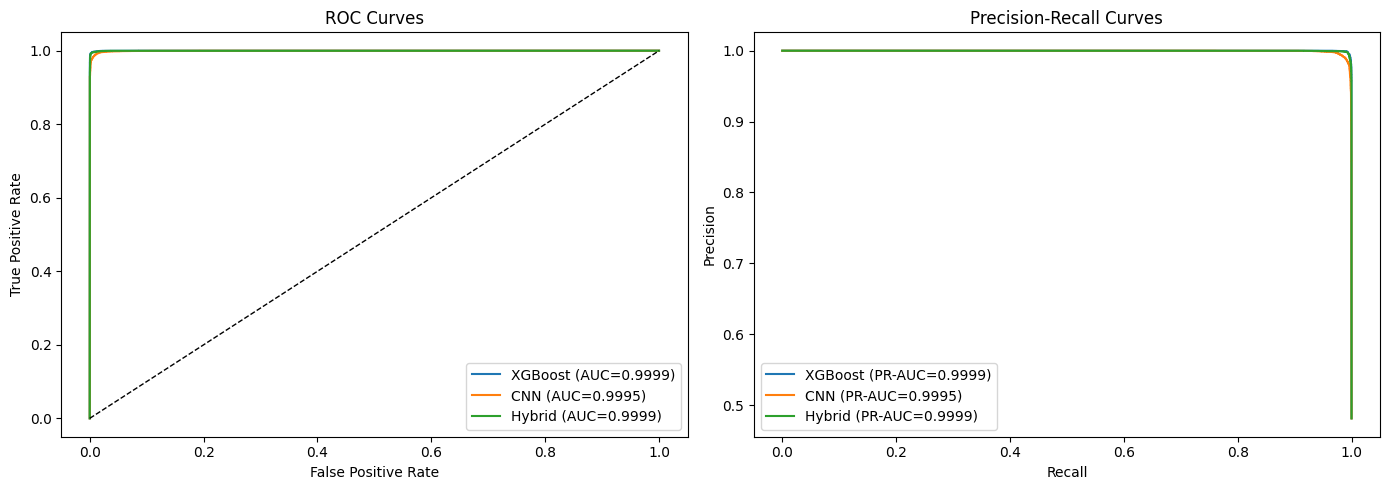

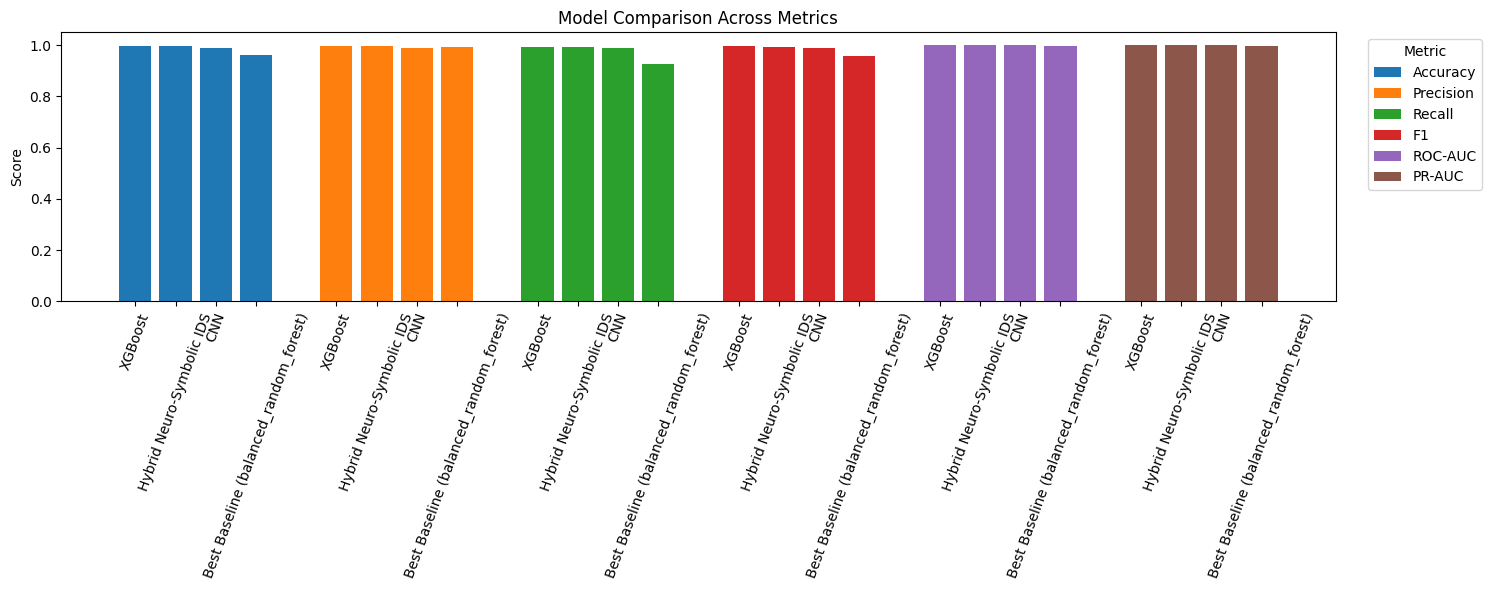

In [16]:
# Section 10: ROC, PR, and metric comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
for name, proba in [
    ("XGBoost", xgb_proba),
    ("CNN", cnn_proba),
    ("Hybrid", hybrid_score),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# PR curves
for name, proba in [
    ("XGBoost", xgb_proba),
    ("CNN", cnn_proba),
    ("Hybrid", hybrid_score),
]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.4f})")

axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

# Bar chart across key metrics
plot_metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
plot_df = comparison_df[["Model", *plot_metrics]].copy()
plot_df_melt = plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(15, 6))
for i, metric in enumerate(plot_metrics):
    metric_slice = plot_df_melt[plot_df_melt["Metric"] == metric]
    x = np.arange(len(metric_slice)) + i * (len(metric_slice) + 1)
    plt.bar(x, metric_slice["Score"].values, label=metric)

xtick_positions = []
xtick_labels = []
n_models = len(plot_df)
for i in range(len(plot_metrics)):
    base = i * (n_models + 1)
    for j in range(n_models):
        xtick_positions.append(base + j)
        xtick_labels.append(plot_df.iloc[j]["Model"])

plt.xticks(xtick_positions, xtick_labels, rotation=70)
plt.ylim(0.0, 1.05)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Interpretable Security Explanations

For selected test samples, we report:

- CNN attack probability
- XGBoost attack probability
- Symbolic rule confidence
- Triggered symbolic rules

This provides analyst-readable explanations for why a connection is classified as attack or normal.

In [17]:
# Section 11: Per-sample interpretable explanations
# Pick representative samples: one high-risk, one borderline, one low-risk
ranked_idx = np.argsort(hybrid_score)
example_positions = [ranked_idx[-1], ranked_idx[len(ranked_idx) // 2], ranked_idx[0]]

for pos in example_positions:
    sample_id = X_test_raw.index[pos]
    fired_ids = symbolic_trace_df.iloc[pos]["triggered_rules"]
    fired_texts = [rule_catalog.get(rule_id, rule_id) for rule_id in fired_ids]
    fired_text = "\n".join([f"- {txt}" for txt in fired_texts]) if fired_texts else "- No symbolic rules triggered"

    explanation = f"""
### Sample Index: {sample_id}

- **CNN attack probability**: {cnn_proba[pos]:.4f}
- **XGBoost attack probability**: {xgb_proba[pos]:.4f}
- **Symbolic rule confidence**: {rule_proba[pos]:.4f}
- **Hybrid score**: {hybrid_score[pos]:.4f}
- **Final class**: {'Attack' if hybrid_pred[pos] == 1 else 'Normal'}

Connection classified as {'attack' if hybrid_pred[pos] == 1 else 'normal'} because:

- CNN detected {'anomalous' if cnn_proba[pos] >= 0.5 else 'non-anomalous'} traffic pattern.
- XGBoost predicted {'high' if xgb_proba[pos] >= 0.5 else 'low'} attack probability.
- Symbolic reasoning evidence:
{fired_text}
"""
    display(Markdown(textwrap.dedent(explanation)))


### Sample Index: 6873

- **CNN attack probability**: 1.0000
- **XGBoost attack probability**: 1.0000
- **Symbolic rule confidence**: 0.1818
- **Hybrid score**: 0.8364
- **Final class**: Attack

Connection classified as attack because:

- CNN detected anomalous traffic pattern.
- XGBoost predicted high attack probability.
- Symbolic reasoning evidence:
- IF numeric__src_bytes <= -0.0077 AND categorical__service_http <= 0.5000 AND numeric__dst_bytes <= -0.0050 AND numeric__logged_in <= 0.1997 THEN attack_confidence += 0.34
- IF serror_rate > 0.7 AND srv_serror_rate > 0.7 THEN attack_confidence += 0.25



### Sample Index: 22030

- **CNN attack probability**: 0.0003
- **XGBoost attack probability**: 0.0529
- **Symbolic rule confidence**: 0.0909
- **Hybrid score**: 0.0421
- **Final class**: Normal

Connection classified as normal because:

- CNN detected non-anomalous traffic pattern.
- XGBoost predicted low attack probability.
- Symbolic reasoning evidence:
- IF numeric__src_bytes <= -0.0077 AND categorical__service_http > 0.5000 AND numeric__dst_host_count > 0.7073 AND numeric__count > -0.6846 THEN attack_confidence += 0.35



### Sample Index: 29995

- **CNN attack probability**: 0.0000
- **XGBoost attack probability**: 0.0000
- **Symbolic rule confidence**: 0.0000
- **Hybrid score**: 0.0000
- **Final class**: Normal

Connection classified as normal because:

- CNN detected non-anomalous traffic pattern.
- XGBoost predicted low attack probability.
- Symbolic reasoning evidence:
- No symbolic rules triggered


## 12. Final Research Discussion

### Performance perspective

The Hybrid Neuro-Symbolic IDS combines complementary strengths:

- CNN captures nonlinear and high-order feature interactions.
- XGBoost provides strong tabular discrimination and calibration.
- Symbolic rules contribute interpretable evidence and analyst-facing rationale.

Compared with standalone learners, hybrid fusion can improve robustness under uncertain traffic regimes while preserving actionable explanations.

### Interpretability perspective

Symbolic reasoning improves interpretability by explicitly exposing **which intrusion heuristics were activated** for each prediction. This is critical for:

- Human validation of alerts
- Post-incident forensic analysis
- Policy and compliance reporting

### Trustworthy AI for cybersecurity

Hybrid IDS systems support trustworthy cybersecurity AI by enabling:

- Explainable alerts for analysts
- Potential reduction of false alarms through multi-signal fusion
- Better operational monitoring and triage
- Transparent, auditable AI decision systems

**Conclusion:** Hybrid Neuro-Symbolic IDS architectures effectively balance predictive accuracy and explainability for practical cybersecurity deployment.

## 13. Save Final Hybrid System

Artifacts are saved under:

- `models/hybrid/`

Saved components:

- XGBoost model
- CNN model
- Symbolic rule set
- Hybrid prediction function

Reproducibility controls:

- `random_state = 42`
- NumPy/TensorFlow seeds initialized earlier

In [18]:
# Section 13: Persist hybrid artifacts
hybrid_dir = PROJECT_ROOT / "models" / "hybrid"
hybrid_dir.mkdir(parents=True, exist_ok=True)

# Save XGBoost model
xgb_out_path = hybrid_dir / "xgboost_model.joblib"
joblib.dump(xgb_model, xgb_out_path)

# Save CNN model
cnn_out_path = hybrid_dir / "cnn_model_2_deep.keras"
cnn_model.save(cnn_out_path)

# Save symbolic rules in a serializable format
symbolic_payload = {
    "random_state": RANDOM_STATE,
    "tree_rules": [
        {
            "id": rule["id"],
            "source": rule["source"],
            "weight": float(rule["weight"]),
            "conditions": [
                [cond[0], cond[1], float(cond[2])] for cond in rule["conditions"]
            ],
            "text": rule["text"],
        }
        for rule in tree_rules
    ],
    "domain_rules": [
        {
            "id": rule["id"],
            "source": rule["source"],
            "weight": float(rule["weight"]),
            "conditions": [
                [cond[0], cond[1], float(cond[2])] for cond in rule["conditions"]
            ],
            "text": rule["text"],
        }
        for rule in domain_rules
    ],
    "fusion_weights": {"xgb": 0.45, "cnn": 0.35, "rules": 0.20},
    "adaptive_thresholds": {
        "rule_confidence_high": 0.7,
        "strong_disagreement": 0.5,
    },
}

symbolic_out_path = hybrid_dir / "symbolic_rule_set.json"
with symbolic_out_path.open("w", encoding="utf-8") as f:
    json.dump(symbolic_payload, f, indent=2)

# Save standalone hybrid prediction function
hybrid_function_code = '''
import numpy as np


def hybrid_predict_proba(xgb_proba, cnn_proba, rule_proba):
    xgb_proba = np.asarray(xgb_proba, dtype=float)
    cnn_proba = np.asarray(cnn_proba, dtype=float)
    rule_proba = np.asarray(rule_proba, dtype=float)

    hybrid_score = (0.45 * xgb_proba) + (0.35 * cnn_proba) + (0.20 * rule_proba)

    high_rule_conf_mask = rule_proba > 0.7
    hybrid_score[high_rule_conf_mask] += 0.10

    strong_disagreement_mask = np.abs(cnn_proba - xgb_proba) > 0.5
    hybrid_score[strong_disagreement_mask] += 0.10 * rule_proba[strong_disagreement_mask]

    return np.clip(hybrid_score, 0.0, 1.0)


def hybrid_predict_label(xgb_proba, cnn_proba, rule_proba, threshold=0.5):
    return (hybrid_predict_proba(xgb_proba, cnn_proba, rule_proba) >= threshold).astype(int)
'''

hybrid_fn_out_path = hybrid_dir / "hybrid_predictor.py"
hybrid_fn_out_path.write_text(textwrap.dedent(hybrid_function_code), encoding="utf-8")

print("Saved hybrid artifacts:")
print(f"- XGBoost model:      {xgb_out_path}")
print(f"- CNN model:          {cnn_out_path}")
print(f"- Symbolic rule set:  {symbolic_out_path}")
print(f"- Hybrid function:    {hybrid_fn_out_path}")

Saved hybrid artifacts:
- XGBoost model:      c:\Users\gudal\OneDrive\Desktop\ShockAwareNeuroSymbolic\models\hybrid\xgboost_model.joblib
- CNN model:          c:\Users\gudal\OneDrive\Desktop\ShockAwareNeuroSymbolic\models\hybrid\cnn_model_2_deep.keras
- Symbolic rule set:  c:\Users\gudal\OneDrive\Desktop\ShockAwareNeuroSymbolic\models\hybrid\symbolic_rule_set.json
- Hybrid function:    c:\Users\gudal\OneDrive\Desktop\ShockAwareNeuroSymbolic\models\hybrid\hybrid_predictor.py


## SECTION - Explainability Evaluation Framework

This section evaluates the explainability of the Hybrid Neuro-Symbolic IDS with reproducible, analyst-oriented metrics and visual evidence.

The analysis assumes previous sections have already produced:

- `xgb_model`
- `xgb_proba`
- `cnn_proba`
- `rule_proba`
- `hybrid_score`
- `hybrid_pred`
- `all_symbolic_rules`
- `symbolic_trace_df`
- `rule_catalog`
- `feature_names`

These outputs are reused to ensure a consistent evaluation pipeline.

### 1. Rule Coverage Metric

Rule coverage measures how often symbolic rules provide at least one explicit explanation for model behavior.

\[
\text{rule\_coverage} = \frac{\text{samples\_with\_triggered\_rules}}{\text{total\_samples}}
\]

A higher value indicates that more predictions are accompanied by rule-based, human-readable reasoning.

Rule Coverage (%): 46.36
Explained samples: 13,772
Unexplained samples: 15,932


,Category,Count
0,Explained samples,13772
1,Unexplained samples,15932


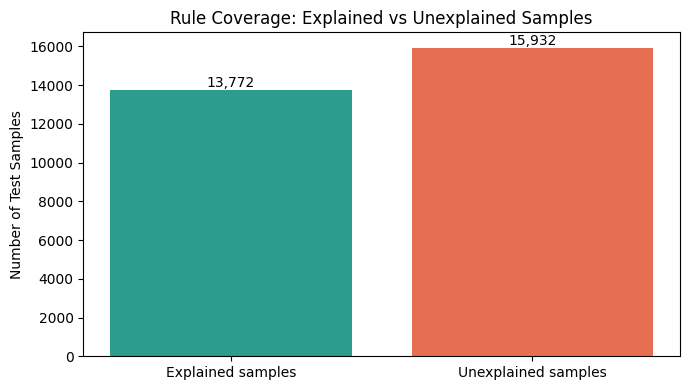

In [19]:
# Explainability 1: Rule coverage metric
explained_samples = int((rule_proba > 0).sum())
total_samples = int(len(rule_proba))
unexplained_samples = total_samples - explained_samples

rule_coverage = explained_samples / total_samples if total_samples else 0.0
rule_coverage_pct = 100.0 * rule_coverage

print(f"Rule Coverage (%): {rule_coverage_pct:.2f}")
print(f"Explained samples: {explained_samples:,}")
print(f"Unexplained samples: {unexplained_samples:,}")

coverage_df = pd.DataFrame(
    {
        "Category": ["Explained samples", "Unexplained samples"],
        "Count": [explained_samples, unexplained_samples],
    }
)

display(coverage_df)

plt.figure(figsize=(7, 4))
bars = plt.bar(
    coverage_df["Category"],
    coverage_df["Count"],
    color=["#2a9d8f", "#e76f51"],
)
for bar in bars:
    y_val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y_val, f"{int(y_val):,}", ha="center", va="bottom")
plt.title("Rule Coverage: Explained vs Unexplained Samples")
plt.ylabel("Number of Test Samples")
plt.tight_layout()
plt.show()

### 2. Rule Complexity Analysis

Rule complexity is measured by the number of conditions in each symbolic rule:

\[
\text{rule\_length} = \text{number of conditions in rule}
\]

Shorter rules are generally easier for security analysts to inspect, validate, and operationalize.

In [20]:
# Explainability 2: Rule complexity analysis
rule_lengths = [len(rule.get("conditions", [])) for rule in all_symbolic_rules]

average_rule_length = float(np.mean(rule_lengths)) if rule_lengths else 0.0
max_rule_length = int(np.max(rule_lengths)) if rule_lengths else 0

rule_complexity_df = pd.DataFrame(
    {
        "rule_id": [rule.get("id", f"RULE_{i+1}") for i, rule in enumerate(all_symbolic_rules)],
        "source": [rule.get("source", "unknown") for rule in all_symbolic_rules],
        "rule_length": rule_lengths,
    }
)

print(f"Average Rule Length: {average_rule_length:.2f}")
print(f"Max Rule Length: {max_rule_length}")

display(rule_complexity_df.sort_values("rule_length", ascending=False).reset_index(drop=True))

Average Rule Length: 3.27
Max Rule Length: 4


,rule_id,source,rule_length
0,TREE_RULE_1,decision_tree,4
1,TREE_RULE_2,decision_tree,4
2,TREE_RULE_3,decision_tree,4
3,TREE_RULE_4,decision_tree,4
4,TREE_RULE_5,decision_tree,4
5,TREE_RULE_6,decision_tree,4
6,TREE_RULE_7,decision_tree,4
7,DOMAIN_RULE_1_SYN_FLOOD,domain,2
8,DOMAIN_RULE_2_BRUTE_FORCE,domain,2
9,DOMAIN_RULE_3_PORT_SCAN,domain,2


### 3. Explanation Fidelity

Explanation fidelity measures agreement between symbolic-rule-driven predictions and final hybrid predictions:

\[
\text{fidelity} = \frac{\text{matching predictions}}{\text{total samples}}
\]

Higher fidelity suggests the explanation layer better reflects the final model behavior.

In [21]:
# Explainability 3: Fidelity between symbolic and hybrid decisions
symbolic_rule_prediction = (rule_proba > 0).astype(int)

fidelity_matches = int((symbolic_rule_prediction == hybrid_pred).sum())
fidelity = fidelity_matches / total_samples if total_samples else 0.0

print(f"Explanation Fidelity: {fidelity:.4f}")
print(f"Matching predictions: {fidelity_matches:,} / {total_samples:,}")

fidelity_df = pd.DataFrame(
    {
        "Metric": ["Explanation Fidelity"],
        "Value": [fidelity],
    }
)
display(fidelity_df)

Explanation Fidelity: 0.9670
Matching predictions: 28,723 / 29,704


,Metric,Value
0,Explanation Fidelity,0.966974


### 4. SHAP Feature Importance

SHAP is used to explain the XGBoost layer by quantifying each feature's contribution to attack probability.

Steps:

1. Build `TreeExplainer` for `xgb_model`
2. Compute SHAP values for the test set
3. Plot SHAP summary
4. Rank features by mean absolute SHAP magnitude (top 10)

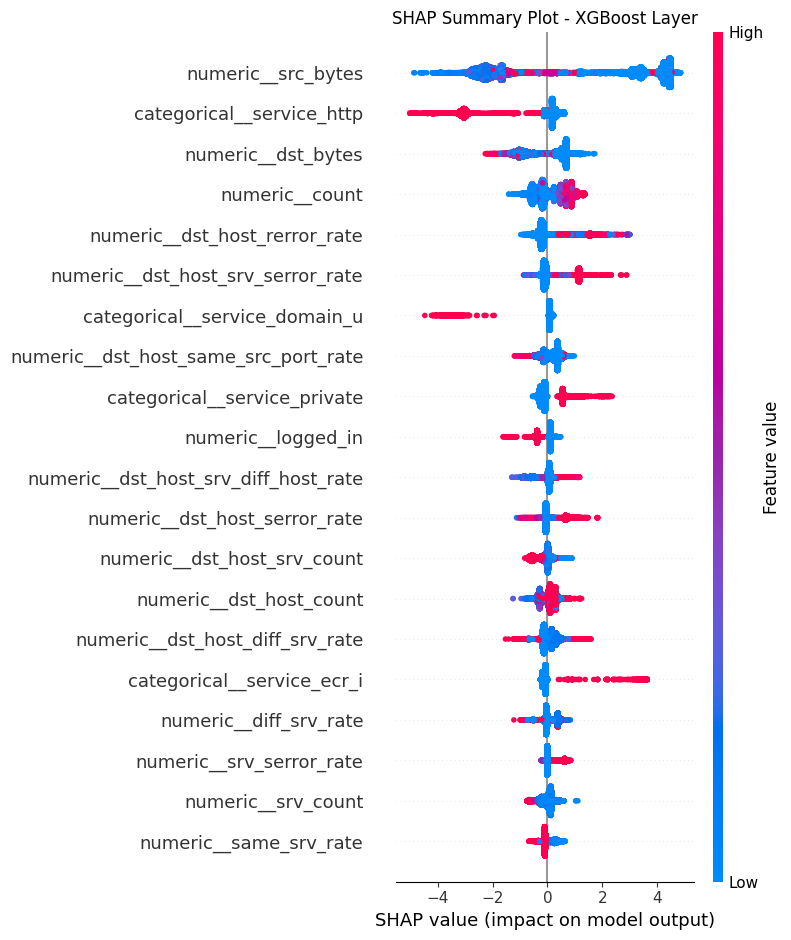

Top 10 SHAP Important Features


,feature,mean_abs_shap
0,numeric__src_bytes,2.760881
1,categorical__service_http,1.116751
2,numeric__dst_bytes,0.728095
3,numeric__count,0.463169
4,numeric__dst_host_rerror_rate,0.426405
5,numeric__dst_host_srv_serror_rate,0.366670
6,categorical__service_domain_u,0.323547
7,numeric__dst_host_same_src_port_rate,0.283780
8,categorical__service_private,0.270900
9,numeric__logged_in,0.229287


Top SHAP-ranked features indicate which traffic attributes most strongly drive the XGBoost intrusion decision. Higher mean absolute SHAP values correspond to stronger influence on attack probability.

In [22]:
# Explainability 4: SHAP feature attribution for XGBoost
try:
    import shap
except Exception:
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

X_shap = to_dense(X_test)

explainer = shap.TreeExplainer(xgb_model)
raw_shap_values = explainer.shap_values(X_shap)

if isinstance(raw_shap_values, list):
    shap_values = raw_shap_values[1] if len(raw_shap_values) > 1 else raw_shap_values[0]
else:
    shap_values = raw_shap_values

if len(np.asarray(shap_values).shape) == 3:
    shap_values = np.asarray(shap_values)[:, :, 1]

shap_values = np.asarray(shap_values)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False,
    max_display=20,
)
plt.title("SHAP Summary Plot - XGBoost Layer")
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "mean_abs_shap": mean_abs_shap,
        }
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

top10_shap_df = shap_importance_df.head(10).copy()

print("Top 10 SHAP Important Features")
display(top10_shap_df)

display(
    Markdown(
        "Top SHAP-ranked features indicate which traffic attributes most strongly drive the XGBoost intrusion decision. "
        "Higher mean absolute SHAP values correspond to stronger influence on attack probability."
    )
)

### 5. Local Explanation Examples

For randomly selected test samples, we report:

- CNN probability
- XGBoost probability
- Rule confidence
- Hybrid score
- Triggered symbolic rules
- Final predicted class

This demonstrates how the hybrid model combines neural learning with symbolic reasoning per connection.

In [23]:
# Explainability 5: Local explanation examples
rng = np.random.default_rng(RANDOM_STATE)
num_examples = min(5, total_samples)
example_positions_local = np.sort(rng.choice(total_samples, size=num_examples, replace=False))

local_explanations = []

for pos in example_positions_local:
    sample_id = X_test_raw.index[pos]
    fired_ids = symbolic_trace_df.iloc[pos]["triggered_rules"]
    fired_rules_text = [rule_catalog.get(rule_id, rule_id) for rule_id in fired_ids]

    record = {
        "sample_id": int(sample_id) if str(sample_id).isdigit() else sample_id,
        "cnn_probability": float(cnn_proba[pos]),
        "xgb_probability": float(xgb_proba[pos]),
        "rule_confidence": float(rule_proba[pos]),
        "hybrid_score": float(hybrid_score[pos]),
        "predicted_class": "Attack" if int(hybrid_pred[pos]) == 1 else "Normal",
        "triggered_rules": fired_rules_text,
    }
    local_explanations.append(record)

    rules_block = (
        "\n".join([f"- {r}" for r in fired_rules_text])
        if fired_rules_text
        else "- No symbolic rule triggered"
    )

    explanation_md = f"""
#### Sample ID: {record['sample_id']}

CNN probability: {record['cnn_probability']:.4f}

XGBoost probability: {record['xgb_probability']:.4f}

Rule confidence: {record['rule_confidence']:.4f}

Triggered Rules:
{rules_block}

Final Hybrid Score: {record['hybrid_score']:.4f}

Predicted Class: {record['predicted_class']}
"""
    display(Markdown(explanation_md))

local_explanations_df = pd.DataFrame(local_explanations)
display(local_explanations_df.drop(columns=["triggered_rules"]))


#### Sample ID: 90130

CNN probability: 0.1630

XGBoost probability: 0.9836

Rule confidence: 0.0000

Triggered Rules:
- No symbolic rule triggered

Final Hybrid Score: 0.4997

Predicted Class: Normal



#### Sample ID: 43414

CNN probability: 0.9998

XGBoost probability: 0.9984

Rule confidence: 0.1818

Triggered Rules:
- IF numeric__src_bytes <= -0.0077 AND categorical__service_http <= 0.5000 AND numeric__dst_bytes <= -0.0050 AND numeric__logged_in <= 0.1997 THEN attack_confidence += 0.34
- IF serror_rate > 0.7 AND srv_serror_rate > 0.7 THEN attack_confidence += 0.25

Final Hybrid Score: 0.8356

Predicted Class: Attack



#### Sample ID: 86001

CNN probability: 0.0000

XGBoost probability: 0.0000

Rule confidence: 0.0000

Triggered Rules:
- No symbolic rule triggered

Final Hybrid Score: 0.0000

Predicted Class: Normal



#### Sample ID: 85218

CNN probability: 0.0000

XGBoost probability: 0.0020

Rule confidence: 0.0000

Triggered Rules:
- No symbolic rule triggered

Final Hybrid Score: 0.0009

Predicted Class: Normal



#### Sample ID: 44601

CNN probability: 0.9998

XGBoost probability: 0.9994

Rule confidence: 0.0909

Triggered Rules:
- IF numeric__src_bytes <= -0.0077 AND categorical__service_http <= 0.5000 AND numeric__dst_bytes <= -0.0050 AND numeric__logged_in <= 0.1997 THEN attack_confidence += 0.34

Final Hybrid Score: 0.8179

Predicted Class: Attack


,sample_id,cnn_probability,xgb_probability,rule_confidence,hybrid_score,predicted_class
0,90130,1.630273e-01,0.983634,0.000000,0.499695,Normal
1,43414,9.998394e-01,0.998366,0.181818,0.835572,Attack
2,86001,2.960917e-11,0.000025,0.000000,0.000011,Normal
3,85218,1.015081e-05,0.002023,0.000000,0.000914,Normal
4,44601,9.998458e-01,0.999383,0.090909,0.817850,Attack


### 6. Visual Explanation Dashboard

The dashboard consolidates explainability evidence into research-friendly visual summaries:

- Rule coverage distribution
- Top SHAP feature importance
- Local sample-level explanation metrics

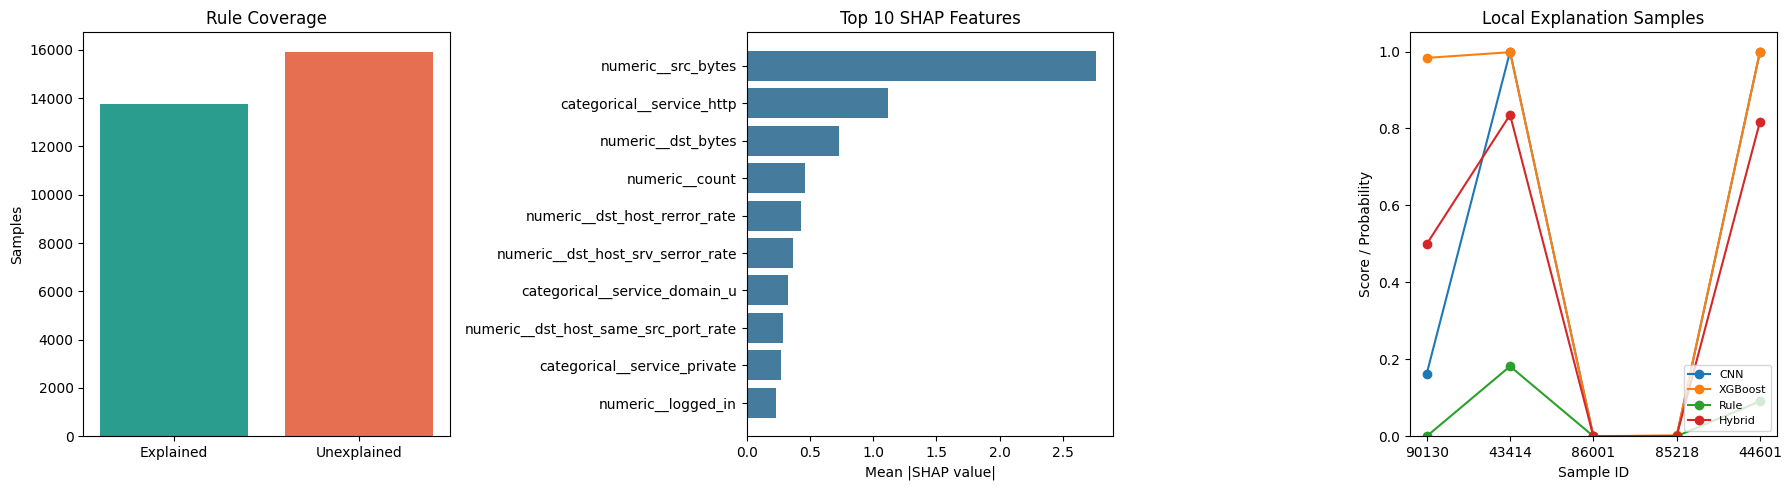

In [24]:
# Explainability 6: Visual explanation dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Rule coverage chart
axes[0].bar(["Explained", "Unexplained"], [explained_samples, unexplained_samples], color=["#2a9d8f", "#e76f51"])
axes[0].set_title("Rule Coverage")
axes[0].set_ylabel("Samples")

# (b) Top SHAP feature importance
top_plot_df = top10_shap_df.sort_values("mean_abs_shap", ascending=True)
axes[1].barh(top_plot_df["feature"], top_plot_df["mean_abs_shap"], color="#457b9d")
axes[1].set_title("Top 10 SHAP Features")
axes[1].set_xlabel("Mean |SHAP value|")

# (c) Local explanation metrics
local_plot_df = local_explanations_df.copy()
local_plot_df["sample_label"] = local_plot_df["sample_id"].astype(str)
axes[2].plot(local_plot_df["sample_label"], local_plot_df["cnn_probability"], marker="o", label="CNN")
axes[2].plot(local_plot_df["sample_label"], local_plot_df["xgb_probability"], marker="o", label="XGBoost")
axes[2].plot(local_plot_df["sample_label"], local_plot_df["rule_confidence"], marker="o", label="Rule")
axes[2].plot(local_plot_df["sample_label"], local_plot_df["hybrid_score"], marker="o", label="Hybrid")
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Local Explanation Samples")
axes[2].set_xlabel("Sample ID")
axes[2].set_ylabel("Score / Probability")
axes[2].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

### 7. Explainability Discussion

The explainability evaluation shows that the hybrid IDS provides interpretable decision reasoning at multiple levels:

- **Symbolic rule layer** contributes human-readable IF-THEN evidence for alert triage.
- **Rule coverage and complexity** quantify how frequently and how simply the model can justify predictions.
- **Fidelity analysis** assesses whether symbolic explanations align with final hybrid decisions.
- **SHAP analysis** highlights which network traffic features most influence XGBoost intrusion probability.

This is critical in operational cybersecurity because:

- Security analysts require transparent rationales to trust and prioritize alerts.
- Incident response teams need concise evidence to accelerate investigation.
- Trustworthy AI deployment depends on both strong performance and auditable logic.

Overall, the Hybrid Neuro-Symbolic IDS delivers both:

- high predictive performance
- transparent decision logic

### 8. Final Note

This explainability framework is designed to run **after hybrid model evaluation**, so it can directly reuse generated probabilities, predictions, symbolic traces, and feature transformations.

Reproducibility controls remain consistent with the notebook setup:

- fixed `random_state = 42`
- deterministic sample selection via seeded random generator
- deterministic metric definitions and visual outputs